In [2]:
# !pip install xgboost

In [5]:
import pymssql
import pandas as pd
import sys
sys.path.append('/path/miniconda3/lib/python3.12/site-packages')
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import joblib
from joblib import dump, load
import xgboost as xgb
import matplotlib.pyplot as plt
import graphviz
from IPython.display import Image, display
from xgboost import plot_tree, plot_importance
import numpy as np
import warnings
from datetime import timedelta
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
def db_connection():
    con = pymssql.connect(user='',password = '',host='',database='',appname='',autocommit = True)
    cursor = con.cursor()
    return con, cursor 
def disconnect(con, cursor):
    con.close()
    cursor.close() 


In [3]:
# query = """select * from All_Claim_Data_2023"""
# conn, cursor = connection_66()
# df = pd.read_sql(query, conn)
# disconnect(conn, cursor)

In [4]:
query = """select * from table"""
conn, cursor = connection_66()
chunksize = 1000000
dfs = []
try:
    cursor.execute(query)
    while True:
        chunk = cursor.fetchmany(chunksize)
        if not chunk:
            break
        dfs.append(pd.DataFrame(chunk, columns=[column[0] for column in cursor.description]))
    df = pd.concat(dfs, ignore_index=True)
    print(f"Shape of DataFrame: {df.shape}")
    print(f"Columns: {df.columns}")
finally:
    disconnect(conn, cursor)

Shape of DataFrame: (9979726, 182)
Columns: Index(['Claim_No', 'Att_Physician', 'Amt_Due', 'Claim_Total', 'Pri_Status',
       'Sec_Status', 'Oth_Status', 'Pat_Status', 'Process_Date',
       'Submission_Type',
       ...
       'Reject_Amount', 'Paid_Proc_Code', 'Charged_Proc_Code', 'Insurance_Id',
       'Check_No', 'EMR_Date_Entry', 'EOB_CODE', 'ERA_CATEGORY_CODE',
       'ERA_ADJUSTMENT_CODE', 'IsRectify'],
      dtype='object', length=182)


In [5]:
df.shape

(9979726, 182)

In [6]:
# df_copy = df.copy()

In [6]:
df['Pri_Status'].unique()

array(['N'], dtype=object)

In [7]:
df['Date_Entry'] = pd.to_datetime(df['Date_Entry'])
df['Process_Date'] = pd.to_datetime(df['Process_Date'])
df['Days'] = (df['Date_Entry'] - df['Process_Date']).dt.days

In [8]:
df['Day_of_Month'] = df['Process_Date'].dt.day
df['Weekday'] = df['Process_Date'].dt.weekday
df['Weekday_Name'] = df['Process_Date'].dt.day_name()

In [9]:
df['Amount_Paid'] = df['Amount_Paid'].fillna(0)
df = df[df['Amount_Paid']>0]

In [10]:
df=df[['Claim_No','Billing_Physician','Amt_Due','Claim_Total','Pri_Status','Sec_Status','Oth_Status','Pat_Status',
    'Submission_Type', 'STATE', 'POS', 'InsPayer_Id','Insurance_State','PLAN_NAME_TYPE','DX_Code1','DX_Code2',
    'DX_Code3','PRIMARY_CARE_PHYSICIAN', 'Provider_Code','Practice_Code', 'TAXONOMY_CODE', 'Procedure_Code',
    'DX_Pointer1','InsName_Id', 'DX_Pointer2', 'DX_Pointer3', 'DX_Pointer4', 'Modi_Code1', 'Modi_Code2',
    'Modi_Code3', 'Modi_Code4', 'Amount','Date_Entry', 'Amount_Approved','units', 'Days', 'Day_of_Month', 'Weekday', 'Process_Date']]

In [11]:
df.shape

(8014513, 39)

In [12]:
df['Modi_Code1'].fillna('', inplace=True)
df['Modi_Code2'].fillna('', inplace=True)
df['Modi_Code3'].fillna('', inplace=True)
df['Modi_Code4'].fillna('', inplace=True)

In [13]:
df['New_Procedure'] = df['Procedure_Code'] + ' ' + df['Modi_Code1'] + ' ' + df['Modi_Code2'] + ' ' +df['Modi_Code3'] + ' ' + df['Modi_Code4']
df['New_Procedure'] =df['New_Procedure'] .str.strip()

In [14]:
df.fillna("1", inplace=True)

In [15]:
df['Amount_Approved'] = pd.to_numeric(df['Amount_Approved'], errors='coerce')
df['Amount_Approved'] = df['Amount_Approved'].fillna(1)

In [16]:
df['median_amount'] = df.groupby(['InsName_Id', 'New_Procedure'])['Amount_Approved'].transform('median')
df['z_score'] = (df['Amount_Approved'] - df['median_amount']) / df.groupby(['InsName_Id', 'New_Procedure'])['Amount_Approved'].transform('std')
df_no_outliers = df[(df['z_score'] <= 3) & (df['z_score'] >= -3)]

In [17]:
df = df_no_outliers.drop(['median_amount', 'z_score'], axis=1)

In [18]:
df=df[df['Amount_Approved']!="1"]
df=df[df['Amount_Approved']>0]

In [19]:
df.shape

(7786976, 40)

In [20]:
procedure_code_counts = df['New_Procedure'].value_counts()
df_filtered = df[df['New_Procedure'].isin(procedure_code_counts[procedure_code_counts > 5].index)]

In [21]:
df_filtered['New_Procedure'].nunique()

3297

In [22]:
df_filtered.columns

Index(['Claim_No', 'Billing_Physician', 'Amt_Due', 'Claim_Total', 'Pri_Status',
       'Sec_Status', 'Oth_Status', 'Pat_Status', 'Submission_Type', 'STATE',
       'POS', 'InsPayer_Id', 'Insurance_State', 'PLAN_NAME_TYPE', 'DX_Code1',
       'DX_Code2', 'DX_Code3', 'PRIMARY_CARE_PHYSICIAN', 'Provider_Code',
       'Practice_Code', 'TAXONOMY_CODE', 'Procedure_Code', 'DX_Pointer1',
       'InsName_Id', 'DX_Pointer2', 'DX_Pointer3', 'DX_Pointer4', 'Modi_Code1',
       'Modi_Code2', 'Modi_Code3', 'Modi_Code4', 'Amount', 'Date_Entry',
       'Amount_Approved', 'units', 'Days', 'Day_of_Month', 'Weekday',
       'Process_Date', 'New_Procedure'],
      dtype='object')

In [24]:
df_filtered = df_filtered.astype(str)
columns_to_encode = [col for col in df_filtered.columns if col not in ['Amount', 'Amt_Due', 'Days', 'Amount_Approved',  'Date_Entry','Process_Date', 'Procedure_Code', 'Claim_Total', 'Claim_No', 'Day_of_Month','Weekday']]
label_encoders = {}
for col in columns_to_encode:
    label_encoders[col] = LabelEncoder()
    df_filtered[col] = label_encoders[col].fit_transform(df_filtered[col])
for col, encoder in label_encoders.items():
    joblib.dump(encoder, f"AllEncodings/{col}_encoding.joblib")

In [1]:
df_filtered.head()

In [ ]:
df_Amount = df_filtered[['Claim_No', 'Billing_Physician', 'Pri_Status', 'Sec_Status', 'Oth_Status', 'Pat_Status', 'Submission_Type',
  'STATE', 'POS', 'InsPayer_Id', 'Insurance_State', 'PLAN_NAME_TYPE', 'DX_Code1', 'DX_Code2', 'DX_Code3', 'PRIMARY_CARE_PHYSICIAN',
    'Provider_Code', 'Practice_Code', 'TAXONOMY_CODE', 'DX_Pointer1', 'InsName_Id', 'DX_Pointer2', 'DX_Pointer3', 'DX_Pointer4', 
    'Modi_Code1', 'Modi_Code2','Modi_Code3', 'Modi_Code4', 'Amount', 'units', 'New_Procedure', 'Amount_Approved', 'Amt_Due', 'Claim_Total']]

In [ ]:
X = df_Amount.drop(['Amount_Approved', 'Amt_Due', 'Claim_Total'], axis=1)
y = df_Amount['Amount_Approved']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [ ]:
X_train.head()

In [28]:
X_train['Claim_No'] = X_train['Claim_No'].astype(int)
X_train['Amount'] = X_train['Amount'].astype(float)

In [29]:
X_test['Claim_No'] = X_test['Claim_No'].astype(int)
X_test['Amount'] = X_test['Amount'].astype(float)

## XGBOOST Concept

In [252]:
display(Image(url="https://miro.medium.com/v2/resize:fit:720/format:webp/1*yAtmzQr7am1lIk_6CuF2KQ.gif"))

## using xgboost 

In [30]:
xgb_regressor = xgb.XGBRegressor(n_estimators=100, random_state=42, max_depth=25, n_jobs=10)

xgb_regressor.fit(X_train, y_train)

y_pred = xgb_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 326.30243143643105
Mean Absolute Error: 0.9141903525887096


In [254]:
dump(xgb_regressor, 'Models/AmountModel.joblib')

['Models/AmountModel.joblib']

<Figure size 1000x800 with 0 Axes>

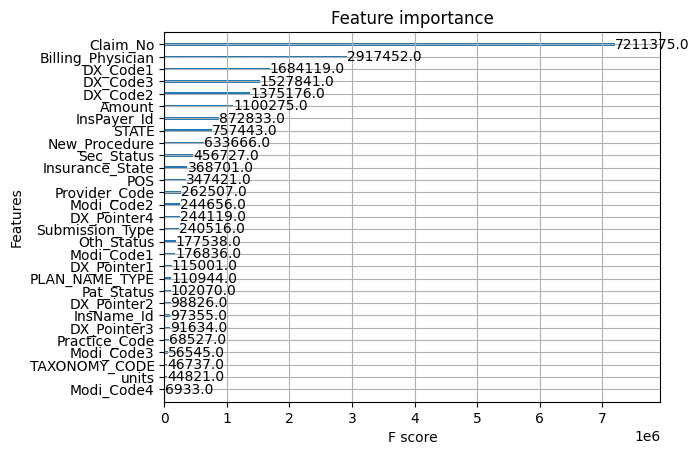

In [31]:
# Plot feature importance
plt.figure(figsize=(10, 8))
plot_importance(xgb_regressor)
plt.show()

## using Random Forest

In [32]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42,n_jobs=10, max_depth=25)

rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 102.30296251450606
Mean Absolute Error: 2.0364280020754957


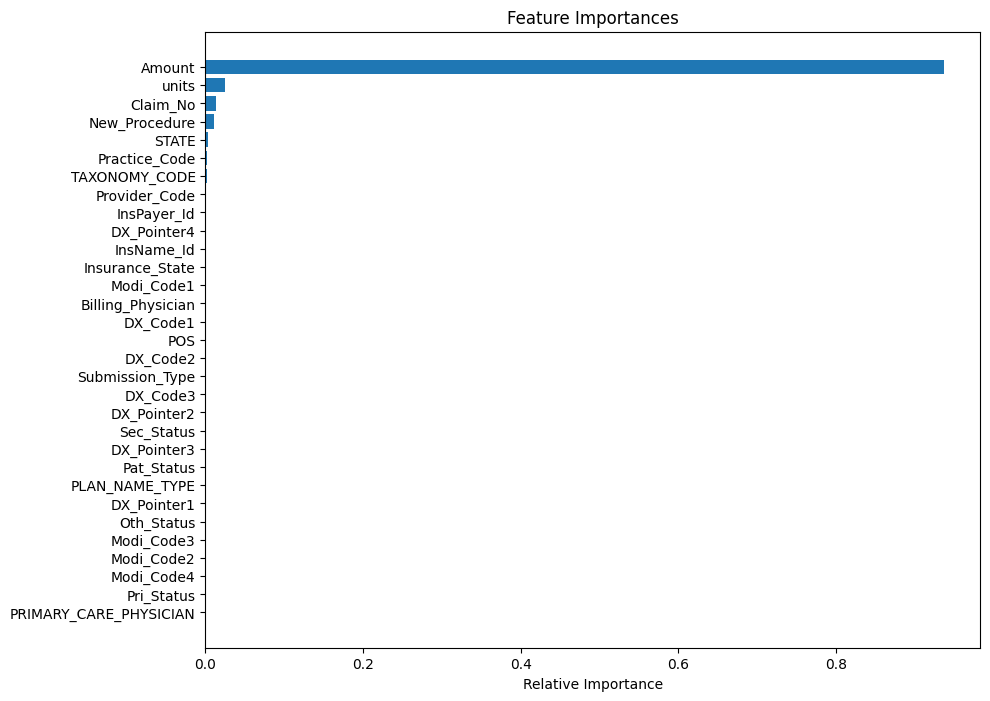

In [33]:
feature_names = X.columns
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [34]:
dump(rf_regressor, 'Models/AmountModel.joblib')

['Models/AmountModel.joblib']

## Area For Amount prediction Service

## For Days Prediction 

In [26]:
def custom_round(value):
        decimal_part = value - np.floor(value)
        if decimal_part >= 0.7:
            return np.ceil(value)
        else:
            return np.floor(value)

In [27]:
df_filtered.columns

Index(['Claim_No', 'Billing_Physician', 'Amt_Due', 'Claim_Total', 'Pri_Status',
       'Sec_Status', 'Oth_Status', 'Pat_Status', 'Submission_Type', 'STATE',
       'POS', 'InsPayer_Id', 'Insurance_State', 'PLAN_NAME_TYPE', 'DX_Code1',
       'DX_Code2', 'DX_Code3', 'PRIMARY_CARE_PHYSICIAN', 'Provider_Code',
       'Practice_Code', 'TAXONOMY_CODE', 'Procedure_Code', 'DX_Pointer1',
       'InsName_Id', 'DX_Pointer2', 'DX_Pointer3', 'DX_Pointer4', 'Modi_Code1',
       'Modi_Code2', 'Modi_Code3', 'Modi_Code4', 'Amount', 'Date_Entry',
       'Amount_Approved', 'units', 'Days', 'Day_of_Month', 'Weekday',
       'Process_Date', 'New_Procedure'],
      dtype='object')

In [28]:
df_days_New = df_filtered[['Claim_No','Billing_Physician','Claim_Total','Pri_Status','Sec_Status','Oth_Status','Pat_Status',
    'Submission_Type', 'STATE', 'POS', 'InsPayer_Id','Insurance_State','PLAN_NAME_TYPE','DX_Code1','DX_Code2',
    'DX_Code3','PRIMARY_CARE_PHYSICIAN', 'Provider_Code','Practice_Code', 'TAXONOMY_CODE', 'Procedure_Code',
    'DX_Pointer1','InsName_Id', 'DX_Pointer2', 'DX_Pointer3', 'DX_Pointer4', 'Modi_Code1', 'Modi_Code2', 'Modi_Code3', 'Modi_Code4',
    'Date_Entry','units', 'Process_Date', 'Days', 'Day_of_Month', 'Weekday', 'New_Procedure']]

In [29]:
df_days = df_days_New.drop(['Date_Entry', 'Process_Date'], axis=1)

In [30]:
df_days.shape

(7784768, 35)

In [31]:
X = df_days.drop(['Claim_No','Procedure_Code', 'Claim_Total', 'Days'], axis=1)  # Features
y = df_days['Days']
X = X.astype(str)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [33]:
# def safe_round(val):
#     return round(int(float(val)))
# X_train['Billing_Physician'] = X_train['Billing_Physician'].apply(safe_round)

In [34]:
# X_train['Billing_Physician'] = X_train['Billing_Physician'].apply(lambda x: round(int(x)))

In [2]:
X_train.head()

In [36]:
X_train = X_train.astype(int)

In [37]:
X_test = X_test.astype(int)

## Using XGBOOST

In [38]:
xgb_regressor = xgb.XGBRegressor(n_estimators=100, random_state=42, max_depth=25, n_jobs=10)

xgb_regressor.fit(X_train, y_train)

y_pred = xgb_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 242.11215150436507
Mean Absolute Error: 3.048591716004214


<Figure size 1000x800 with 0 Axes>

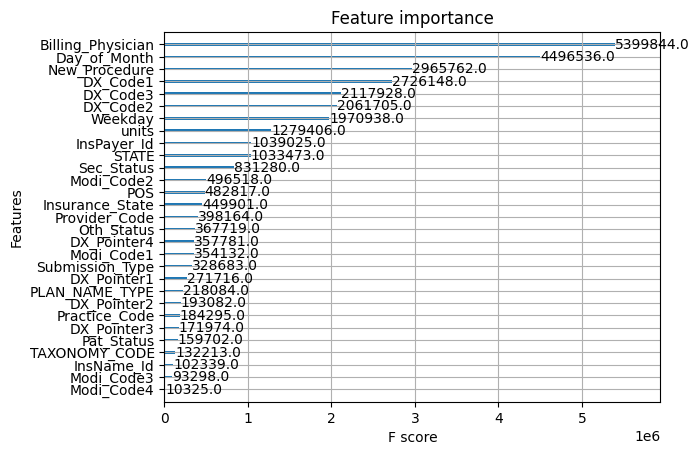

In [39]:
# Plot feature importance
plt.figure(figsize=(10, 8))
plot_importance(xgb_regressor)
plt.show()

In [43]:
dump(xgb_regressor, 'Models/XGBOOSTDaysModel.joblib')

['Models/XGBOOSTDaysModel.joblib']

## Using Random Forest

In [41]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42,n_jobs=10, max_depth=25)

rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 241.03035781919078
Mean Absolute Error: 4.316929286651556


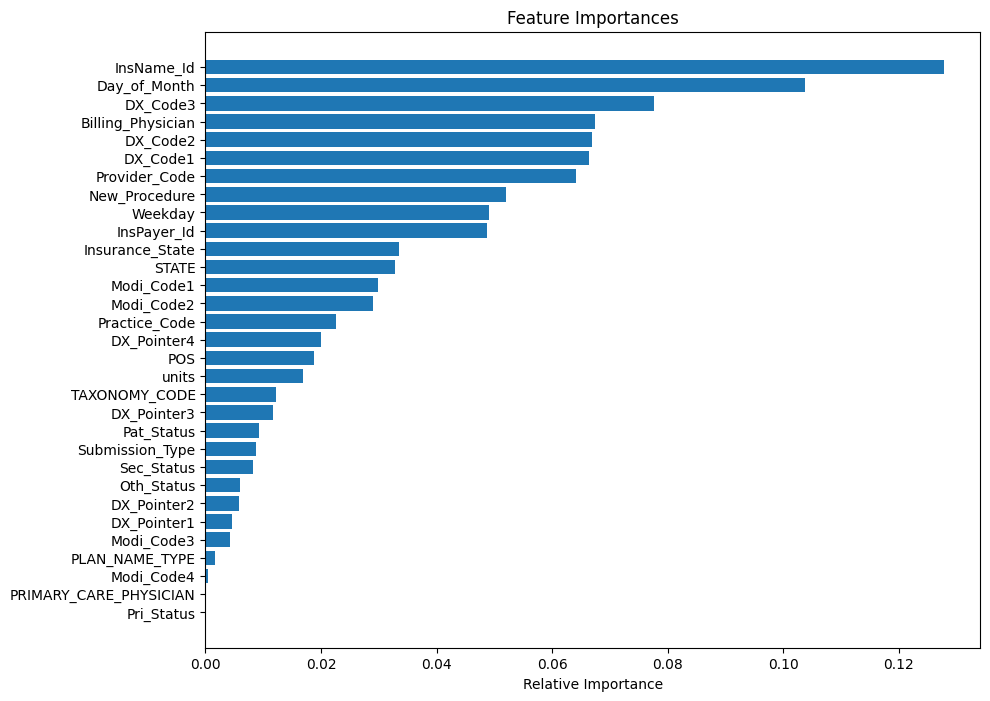

In [42]:
feature_names = X.columns
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [44]:
dump(rf_regressor, 'Models/RFDaysModel.joblib')

['Models/RFDaysModel.joblib']

## Area for Prediction Service

In [304]:
def fetch_data_from_sql(query_date):
    query = f"""query"""
    conn, cursor = connection_76()
    df = pd.read_sql(query, conn)
    disconnect(conn, cursor)
    return df

In [305]:
def preprocess_data(df):
    df['Process_Date'] = pd.to_datetime(df['Process_Date'])
    df['Day_of_Month'] = df['Process_Date'].dt.day
    df['Weekday'] = df['Process_Date'].dt.weekday
    df['Weekday_Name'] = df['Process_Date'].dt.day_name()
    df=df[['Claim_No','Billing_Physician','Amt_Due','Claim_Total','Pri_Status','Sec_Status','Oth_Status','Pat_Status',
    'Submission_Type', 'STATE', 'POS', 'InsPayer_Id','Insurance_State','PLAN_NAME_TYPE','DX_Code1','DX_Code2',
    'DX_Code3','PRIMARY_CARE_PHYSICIAN', 'Provider_Code','Practice_Code', 'TAXONOMY_CODE', 'Procedure_Code',
    'DX_Pointer1','InsName_Id', 'DX_Pointer2', 'DX_Pointer3', 'DX_Pointer4', 'Modi_Code1', 'Modi_Code2',
    'Modi_Code3', 'Modi_Code4', 'Amount', 'units', 'Day_of_Month', 'Weekday', 'Process_Date']]
    df['Modi_Code1'].fillna('', inplace=True)
    df['Modi_Code2'].fillna('', inplace=True)
    df['Modi_Code3'].fillna('', inplace=True)
    df['Modi_Code4'].fillna('', inplace=True)
    df['New_Procedure'] = df['Procedure_Code'] + ' ' + df['Modi_Code1'] + ' ' + df['Modi_Code2'] + ' ' +df['Modi_Code3'] + ' ' + df['Modi_Code4']
    df['New_Procedure'] =df['New_Procedure'] .str.strip()
    df.fillna("1", inplace=True)
    return df

In [346]:
def transform_data(df_filtered):
    new_df = df_filtered.copy()
    columns_to_encode = [col for col in df_filtered.columns if col not in ['Amount', 'Amt_Due', 'Days', 'Amount_Approved', 'Date_Entry', 'Process_Date', 'Procedure_Code', 'Claim_Total', 'Claim_No', 'Day_of_Month', 'Weekday']]
    for col in columns_to_encode:
        encoder = joblib.load(f"AllEncodings/{col}_encoding.joblib")
        new_df[col] = df_filtered[col].astype(str).apply(lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1)
    
    return new_df

In [347]:
# def transform_data(df_filtered):
#     columns_to_encode = [col for col in df_filtered.columns if col not in ['Amount', 'Amt_Due', 'Days', 'Amount_Approved', 'Date_Entry', 'Process_Date', 'Procedure_Code', 'Claim_Total', 'Claim_No', 'Day_of_Month', 'Weekday']]
#     print(columns_to_encode)
#     for col in columns_to_encode:
#         encoder = joblib.load(f"AllEncodings/{col}_encoding.joblib")
#         df_filtered[col] = encoder.transform(df_filtered[col].astype(str))
#     return df_filtered

In [348]:
def predict_amount(df):
    df = df[['Claim_No', 'Billing_Physician', 'Pri_Status', 'Sec_Status', 'Oth_Status', 'Pat_Status', 'Submission_Type',
  'STATE', 'POS', 'InsPayer_Id', 'Insurance_State', 'PLAN_NAME_TYPE', 'DX_Code1', 'DX_Code2', 'DX_Code3', 'PRIMARY_CARE_PHYSICIAN',
    'Provider_Code', 'Practice_Code', 'TAXONOMY_CODE', 'DX_Pointer1', 'InsName_Id', 'DX_Pointer2', 'DX_Pointer3', 'DX_Pointer4', 
    'Modi_Code1', 'Modi_Code2','Modi_Code3', 'Modi_Code4', 'Amount', 'units', 'New_Procedure']]
    
    amount_model = joblib.load("Models/AmountModel.joblib")
    
    predictions = amount_model.predict(df)
    
    return predictions

In [349]:
def predict_days(df):
    df = df[['Billing_Physician','Pri_Status','Sec_Status','Oth_Status','Pat_Status',
    'Submission_Type', 'STATE', 'POS', 'InsPayer_Id','Insurance_State','PLAN_NAME_TYPE','DX_Code1','DX_Code2',
    'DX_Code3','PRIMARY_CARE_PHYSICIAN', 'Provider_Code','Practice_Code', 'TAXONOMY_CODE', 
    'DX_Pointer1','InsName_Id', 'DX_Pointer2', 'DX_Pointer3', 'DX_Pointer4', 'Modi_Code1', 'Modi_Code2', 'Modi_Code3', 'Modi_Code4',
    'units', 'Day_of_Month', 'Weekday', 'New_Procedure']]

    days_model = joblib.load("Models/DaysModel.joblib")

    predictions = days_model.predict(df)
    
    return predictions

In [350]:
main_df = fetch_data_from_sql('2024-06-20')

In [351]:
main_df.shape

(9298, 163)

In [352]:
processed_df = preprocess_data(main_df)

In [354]:
transformed_df = transform_data(processed_df)

In [356]:
Amount_prediction = predict_amount(transformed_df)

In [357]:
Days_prediction = predict_days(transformed_df)

In [358]:
processed_df['Predicted_Amount'] = Amount_prediction
processed_df['Predicted_Days'] = Days_prediction

In [359]:
processed_df['Predicted_Days'] = processed_df['Predicted_Days'].apply(custom_round).astype(int)

In [360]:
processed_df['Process_Date'] = pd.to_datetime(processed_df['Process_Date'])  
processed_df['Predicted_date'] = processed_df['Process_Date'] + processed_df['Predicted_Days'].apply(lambda x: timedelta(days=x))

In [3]:
processed_df[['Claim_No', 'New_Procedure', 'Amount', 'Predicted_Amount', 'Process_Date', 'Predicted_Days', 'Predicted_date']].head(25)